In [270]:
import os
import pandas as pd
import pmdarima as pm
from pmdarima import model_selection
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np
import warnings
import math
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import tabulate

In [271]:
def cast_to_time(df):
    df['time'] = pd.to_datetime(df['time'])
    return df

In [272]:
data_dir = '../Data/Preprocessed'
base_paths = os.listdir(data_dir)
full_paths = [os.path.join(data_dir, p) for p in base_paths]
patients = {base_paths[i].split('.')[0] : cast_to_time(pd.read_csv(fp, sep=';')) for i, fp in enumerate(full_paths)}
ids = list(patients.keys())

In [273]:
too_long = ["HUPA0027P", "HUPA0028P", "HUPA0026P"]
for i in too_long:
    ids.remove(i)
    s = 1.5

In [274]:
warnings.filterwarnings("ignore")

# Time Series cross validation split

In [275]:
def get_metrics(order : tuple, test : int, t : int, patients : dict):
    metrics = []
    for i in ids:
        print(f"patient : {i}")
        ts = patients[i].loc[:, "glucose"]
        tscv = TimeSeriesSplit(n_splits=5, test_size = test)

        # Store the Mean Squared Errors (MSE) from each fold
        mse_scores = []
        mape_scores = []
        r_2_scores = []
        fold_results = []
        f = 1

        # Iterate through the splits
        for (train_index, test_index) in tscv.split(ts):
            print(train_index)
            print(test_index)
            # Split the data
            cv_train = ts[train_index]
            cv_test = ts[test_index]


            cv_model = pm.ARIMA(order = order)
            cv_model.fit(cv_train)

            # --- Make Predictions on the Test Fold ---
            # The 'n_periods' is the length of the test set
            forecast, conf_int = cv_model.predict(n_periods=len(cv_test), return_conf_int=True)

            # --- Evaluate ---
            mse = mean_squared_error(cv_test, forecast)
            mape = mean_absolute_percentage_error(cv_test, forecast)
            r_2 = r2_score(cv_test, forecast)
            mse_scores.append(mse)
            mape_scores.append(mape)
            r_2_scores.append(r_2)
            # Store results for plotting
            fold_results.append({
                'train_data': ts[train_index],
                'test_data': ts[test_index],
                'forecast': pd.Series(forecast, index = ts[test_index])
            })

            print(f"Fold: {f}")
            time.sleep(t/5)
            f += 1

        # Calculate and print the overall cross-validation score
        avg_mse = np.mean(mse_scores)
        avg_mape = np.mean(mape_scores)
        avg_r2 = np.mean(r_2_scores)
        metric = [avg_mse, avg_mape, avg_r2]
        print(f"\nAverage Cross-Validation MSE: {avg_mse:.2f}")
        print(f"\nAverage Cross-Validation MAPE: {avg_mape:.2f}")
        print(f"\nAverage Cross-Validation R2: {avg_r2:.2f}")
        
        metrics.append(metric)
        time.sleep(t/3)
    
    return metrics

## 15 min

In [276]:
p = 4
d = 0
q = 3

metrics_d0_15min = get_metrics(order = (p,d,q), test = 3, t = 1.2, patients = patients) # test = unit shfit, t = seconds

patient : HUPA0018P
[   0    1    2 ... 3877 3878 3879]
[3880 3881 3882]
Fold: 1
[   0    1    2 ... 3880 3881 3882]
[3883 3884 3885]
Fold: 2
[   0    1    2 ... 3883 3884 3885]
[3886 3887 3888]
Fold: 3
[   0    1    2 ... 3886 3887 3888]
[3889 3890 3891]
Fold: 4
[   0    1    2 ... 3889 3890 3891]
[3892 3893 3894]
Fold: 5

Average Cross-Validation MSE: 112.27

Average Cross-Validation MAPE: 0.06

Average Cross-Validation R2: -4.50
patient : HUPA0014P
[   0    1    2 ... 3811 3812 3813]
[3814 3815 3816]
Fold: 1
[   0    1    2 ... 3814 3815 3816]
[3817 3818 3819]
Fold: 2
[   0    1    2 ... 3817 3818 3819]
[3820 3821 3822]
Fold: 3
[   0    1    2 ... 3820 3821 3822]
[3823 3824 3825]
Fold: 4
[   0    1    2 ... 3823 3824 3825]
[3826 3827 3828]
Fold: 5

Average Cross-Validation MSE: 76.82

Average Cross-Validation MAPE: 0.04

Average Cross-Validation R2: -1.71
patient : HUPA0019P
[   0    1    2 ... 3693 3694 3695]
[3696 3697 3698]
Fold: 1
[   0    1    2 ... 3696 3697 3698]
[3699 3700 3

In [277]:
p = 4
d = 1
q = 3

metrics_d1_15min = get_metrics(order = (p,d,q), test = 3, t = 1.2, patients = patients)

patient : HUPA0018P
[   0    1    2 ... 3877 3878 3879]
[3880 3881 3882]
Fold: 1
[   0    1    2 ... 3880 3881 3882]
[3883 3884 3885]
Fold: 2
[   0    1    2 ... 3883 3884 3885]
[3886 3887 3888]
Fold: 3
[   0    1    2 ... 3886 3887 3888]
[3889 3890 3891]
Fold: 4
[   0    1    2 ... 3889 3890 3891]
[3892 3893 3894]
Fold: 5

Average Cross-Validation MSE: 105.35

Average Cross-Validation MAPE: 0.06

Average Cross-Validation R2: -3.16
patient : HUPA0014P
[   0    1    2 ... 3811 3812 3813]
[3814 3815 3816]
Fold: 1
[   0    1    2 ... 3814 3815 3816]
[3817 3818 3819]
Fold: 2
[   0    1    2 ... 3817 3818 3819]
[3820 3821 3822]
Fold: 3
[   0    1    2 ... 3820 3821 3822]
[3823 3824 3825]
Fold: 4
[   0    1    2 ... 3823 3824 3825]
[3826 3827 3828]
Fold: 5

Average Cross-Validation MSE: 75.05

Average Cross-Validation MAPE: 0.04

Average Cross-Validation R2: -1.70
patient : HUPA0019P
[   0    1    2 ... 3693 3694 3695]
[3696 3697 3698]
Fold: 1
[   0    1    2 ... 3696 3697 3698]
[3699 3700 3

In [278]:
m_d0 = np.array(metrics_d0_15min)
m_d1 = np.array(metrics_d1_15min)
l = len(m_d0)
zeros = [0 for i in range(l)]
ones = [1 for i in range(l)]
df_d0 = pd.DataFrame({
    "type" : zeros,
    "mse" : m_d0[:,0],
    "mape" : m_d0[:,1],
    "r2" : m_d0[:,2],
})
df_d1 = pd.DataFrame({
    "type" : ones,
    "mse" : m_d1[:,0],
    "mape" : m_d1[:,1],
    "r2" : m_d1[:,2],
})

general_metrics_15min = pd.concat([df_d0, df_d1])

<Axes: xlabel='mse'>

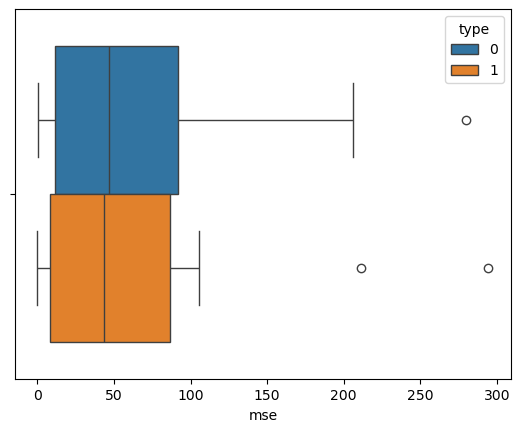

In [279]:
sns.boxplot(data = general_metrics_15min, x = "mse", hue = "type")

<Axes: xlabel='mape'>

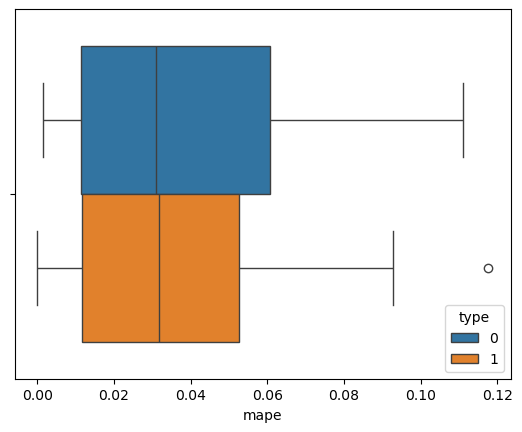

In [280]:
sns.boxplot(data = general_metrics_15min, x = "mape", hue = "type")

<Axes: xlabel='r2'>

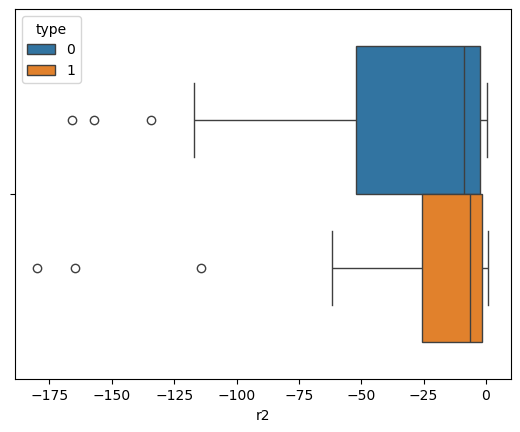

In [281]:
sns.boxplot(data = general_metrics_15min, x = "r2", hue = "type")

## 30 min

In [282]:
p = 4
d = 0
q = 3

metrics_d0_30min = get_metrics(order = (p,d,q), test = 6, t = 1.2, patients = patients) # test = unit shfit, t = seconds

patient : HUPA0018P
[   0    1    2 ... 3862 3863 3864]
[3865 3866 3867 3868 3869 3870]
Fold: 1
[   0    1    2 ... 3868 3869 3870]
[3871 3872 3873 3874 3875 3876]
Fold: 2
[   0    1    2 ... 3874 3875 3876]
[3877 3878 3879 3880 3881 3882]
Fold: 3
[   0    1    2 ... 3880 3881 3882]
[3883 3884 3885 3886 3887 3888]
Fold: 4
[   0    1    2 ... 3886 3887 3888]
[3889 3890 3891 3892 3893 3894]
Fold: 5

Average Cross-Validation MSE: 394.92

Average Cross-Validation MAPE: 0.13

Average Cross-Validation R2: -1.03
patient : HUPA0014P
[   0    1    2 ... 3796 3797 3798]
[3799 3800 3801 3802 3803 3804]
Fold: 1
[   0    1    2 ... 3802 3803 3804]
[3805 3806 3807 3808 3809 3810]
Fold: 2
[   0    1    2 ... 3808 3809 3810]
[3811 3812 3813 3814 3815 3816]
Fold: 3
[   0    1    2 ... 3814 3815 3816]
[3817 3818 3819 3820 3821 3822]
Fold: 4
[   0    1    2 ... 3820 3821 3822]
[3823 3824 3825 3826 3827 3828]
Fold: 5

Average Cross-Validation MSE: 163.60

Average Cross-Validation MAPE: 0.05

Average Cross

In [283]:
p = 4
d = 1
q = 3

metrics_d1_30min = get_metrics(order = (p,d,q), test = 6, t = 1.2, patients = patients) # test = unit shfit, t = seconds

patient : HUPA0018P
[   0    1    2 ... 3862 3863 3864]
[3865 3866 3867 3868 3869 3870]
Fold: 1
[   0    1    2 ... 3868 3869 3870]
[3871 3872 3873 3874 3875 3876]
Fold: 2
[   0    1    2 ... 3874 3875 3876]
[3877 3878 3879 3880 3881 3882]
Fold: 3
[   0    1    2 ... 3880 3881 3882]
[3883 3884 3885 3886 3887 3888]
Fold: 4
[   0    1    2 ... 3886 3887 3888]
[3889 3890 3891 3892 3893 3894]
Fold: 5

Average Cross-Validation MSE: 474.95

Average Cross-Validation MAPE: 0.13

Average Cross-Validation R2: -1.61
patient : HUPA0014P
[   0    1    2 ... 3796 3797 3798]
[3799 3800 3801 3802 3803 3804]
Fold: 1
[   0    1    2 ... 3802 3803 3804]
[3805 3806 3807 3808 3809 3810]
Fold: 2
[   0    1    2 ... 3808 3809 3810]
[3811 3812 3813 3814 3815 3816]
Fold: 3
[   0    1    2 ... 3814 3815 3816]
[3817 3818 3819 3820 3821 3822]
Fold: 4
[   0    1    2 ... 3820 3821 3822]
[3823 3824 3825 3826 3827 3828]
Fold: 5

Average Cross-Validation MSE: 150.97

Average Cross-Validation MAPE: 0.05

Average Cross

In [284]:
m_d0 = np.array(metrics_d0_30min)
m_d1 = np.array(metrics_d1_30min)
l = len(m_d0)
zeros = [0 for i in range(l)]
ones = [1 for i in range(l)]
df_d0 = pd.DataFrame({
    "type" : zeros,
    "mse" : m_d0[:,0],
    "mape" : m_d0[:,1],
    "r2" : m_d0[:,2],
})
df_d1 = pd.DataFrame({
    "type" : ones,
    "mse" : m_d1[:,0],
    "mape" : m_d1[:,1],
    "r2" : m_d1[:,2],
})

general_metrics_30min = pd.concat([df_d0, df_d1])

<Axes: xlabel='mse'>

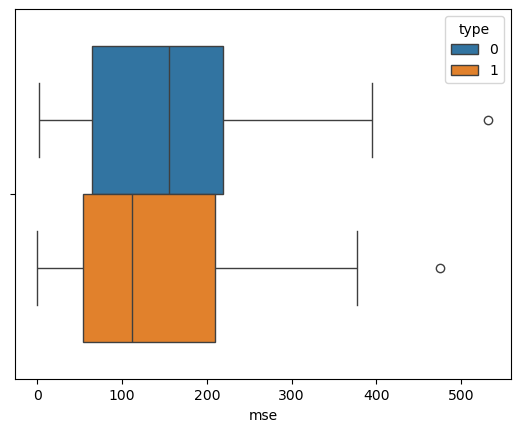

In [285]:
sns.boxplot(data = general_metrics_30min, x = "mse", hue = "type")

<Axes: xlabel='mape'>

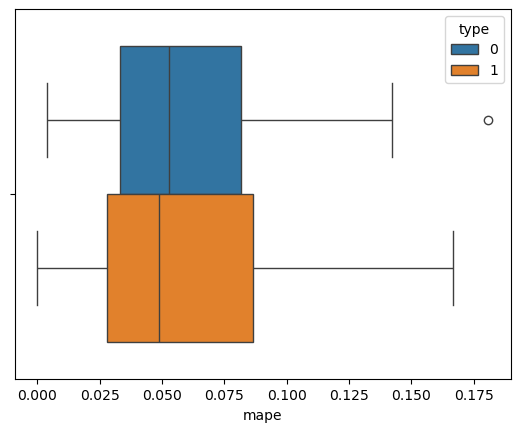

In [286]:
sns.boxplot(data = general_metrics_30min, x = "mape", hue = "type")

<Axes: xlabel='r2'>

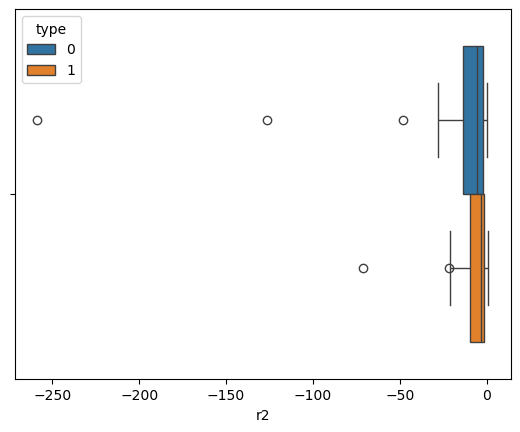

In [287]:
sns.boxplot(data = general_metrics_30min, x = "r2", hue = "type")

## 60 min

In [288]:
p = 4
d = 0
q = 3

metrics_d0_60min = get_metrics(order = (p,d,q), test = 12, t = 1.2, patients = patients)

patient : HUPA0018P
[   0    1    2 ... 3832 3833 3834]
[3835 3836 3837 3838 3839 3840 3841 3842 3843 3844 3845 3846]
Fold: 1
[   0    1    2 ... 3844 3845 3846]
[3847 3848 3849 3850 3851 3852 3853 3854 3855 3856 3857 3858]
Fold: 2
[   0    1    2 ... 3856 3857 3858]
[3859 3860 3861 3862 3863 3864 3865 3866 3867 3868 3869 3870]
Fold: 3
[   0    1    2 ... 3868 3869 3870]
[3871 3872 3873 3874 3875 3876 3877 3878 3879 3880 3881 3882]
Fold: 4
[   0    1    2 ... 3880 3881 3882]
[3883 3884 3885 3886 3887 3888 3889 3890 3891 3892 3893 3894]
Fold: 5

Average Cross-Validation MSE: 730.16

Average Cross-Validation MAPE: 0.25

Average Cross-Validation R2: -15.30
patient : HUPA0014P
[   0    1    2 ... 3766 3767 3768]
[3769 3770 3771 3772 3773 3774 3775 3776 3777 3778 3779 3780]
Fold: 1
[   0    1    2 ... 3778 3779 3780]
[3781 3782 3783 3784 3785 3786 3787 3788 3789 3790 3791 3792]
Fold: 2
[   0    1    2 ... 3790 3791 3792]
[3793 3794 3795 3796 3797 3798 3799 3800 3801 3802 3803 3804]
Fold: 3


In [289]:
p = 4
d = 1
q = 3

metrics_d1_60min = get_metrics(order = (p,d,q), test = 12, t = 1.2, patients = patients)

patient : HUPA0018P
[   0    1    2 ... 3832 3833 3834]
[3835 3836 3837 3838 3839 3840 3841 3842 3843 3844 3845 3846]
Fold: 1
[   0    1    2 ... 3844 3845 3846]
[3847 3848 3849 3850 3851 3852 3853 3854 3855 3856 3857 3858]
Fold: 2
[   0    1    2 ... 3856 3857 3858]
[3859 3860 3861 3862 3863 3864 3865 3866 3867 3868 3869 3870]
Fold: 3
[   0    1    2 ... 3868 3869 3870]
[3871 3872 3873 3874 3875 3876 3877 3878 3879 3880 3881 3882]
Fold: 4
[   0    1    2 ... 3880 3881 3882]
[3883 3884 3885 3886 3887 3888 3889 3890 3891 3892 3893 3894]
Fold: 5

Average Cross-Validation MSE: 920.29

Average Cross-Validation MAPE: 0.14

Average Cross-Validation R2: -1.74
patient : HUPA0014P
[   0    1    2 ... 3766 3767 3768]
[3769 3770 3771 3772 3773 3774 3775 3776 3777 3778 3779 3780]
Fold: 1
[   0    1    2 ... 3778 3779 3780]
[3781 3782 3783 3784 3785 3786 3787 3788 3789 3790 3791 3792]
Fold: 2
[   0    1    2 ... 3790 3791 3792]
[3793 3794 3795 3796 3797 3798 3799 3800 3801 3802 3803 3804]
Fold: 3
[

In [290]:
m_d0 = np.array(metrics_d0_60min)
m_d1 = np.array(metrics_d1_60min)
l = len(m_d0)
zeros = [0 for i in range(l)]
ones = [1 for i in range(l)]
df_d0 = pd.DataFrame({
    "type" : zeros,
    "mse" : m_d0[:,0],
    "mape" : m_d0[:,1],
    "r2" : m_d0[:,2],
})
df_d1 = pd.DataFrame({
    "type" : ones,
    "mse" : m_d1[:,0],
    "mape" : m_d1[:,1],
    "r2" : m_d1[:,2],
})

general_metrics_60min = pd.concat([df_d0, df_d1])

<Axes: xlabel='mse'>

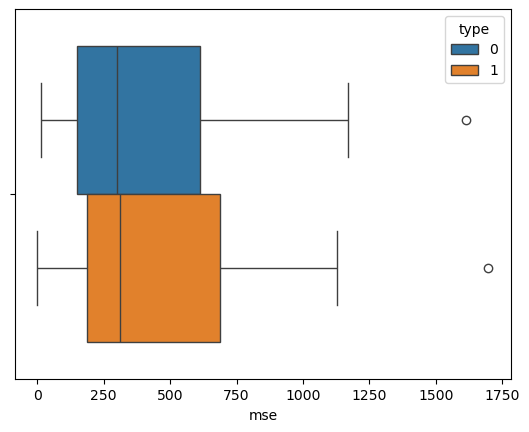

In [291]:
sns.boxplot(data = general_metrics_60min, x = "mse", hue = "type")

<Axes: xlabel='mape'>

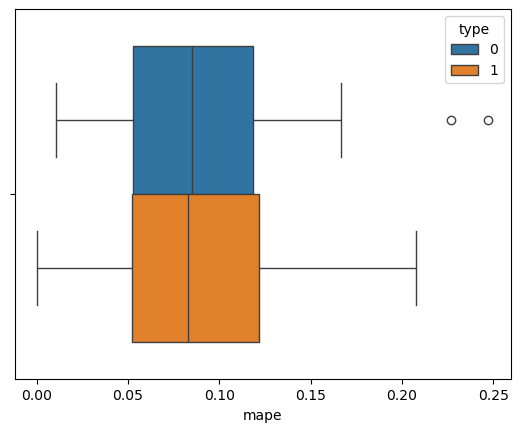

In [292]:
sns.boxplot(data = general_metrics_60min, x = "mape", hue = "type")

# Results

In [293]:
l = len(general_metrics_30min)
general_metrics_15min["forecast"] = [15 for i in range(l)]
general_metrics_30min["forecast"] = [30 for i in range(l)]
general_metrics_60min["forecast"] = [60 for i in range(l)]

In [294]:
general_metrics = pd.concat([general_metrics_15min, general_metrics_30min, general_metrics_60min])

In [295]:
d0_mean = general_metrics[general_metrics["type"] == 0]["mse"].mean()
d1_mean = general_metrics[general_metrics["type"] == 1]["mse"].mean()
d0_median = general_metrics[general_metrics["type"] == 0]["mse"].median()
d1_median = general_metrics[general_metrics["type"] == 1]["mse"].median()
d0_std = general_metrics[general_metrics["type"] == 0]["mse"].std()
d1_std = general_metrics[general_metrics["type"] == 1]["mse"].std()

header = ["Agg func", "Diff 0", "Diff 1"]
data = [
    ["mean", round(d0_mean, 3), round(d1_mean, 3)],
    ["median", round(d0_median, 3) , round(d1_median, 3)],
    ["std", round(d0_std, 3) , round(d1_std, 3)],
    ]
print("MSE")
print(tabulate.tabulate(data, headers = header, tablefmt = "simple"))

MSE
Agg func      Diff 0    Diff 1
----------  --------  --------
mean         227.304   220.191
median       114.459   102.063
std          310.758   304.692


In [296]:
d0_mean = general_metrics[general_metrics["type"] == 0]["mape"].mean()
d1_mean = general_metrics[general_metrics["type"] == 1]["mape"].mean()
d0_median = general_metrics[general_metrics["type"] == 0]["mape"].median()
d1_median = general_metrics[general_metrics["type"] == 1]["mape"].median()
d0_std = general_metrics[general_metrics["type"] == 0]["mape"].std()
d1_std = general_metrics[general_metrics["type"] == 1]["mape"].std()


header = ["Agg func", "Diff 0", "Diff 1"]
data = [
    ["mean", round(d0_mean, 3), round(d1_mean, 3)],
    ["median", round(d0_median, 3) , round(d1_median, 3)],
    ["std", round(d0_std, 3) , round(d1_std, 3)],
    ]
print("MAPE")
print(tabulate.tabulate(data, headers = header, tablefmt = "simple"))

MAPE
Agg func      Diff 0    Diff 1
----------  --------  --------
mean           0.066     0.063
median         0.056     0.052
std            0.052     0.047


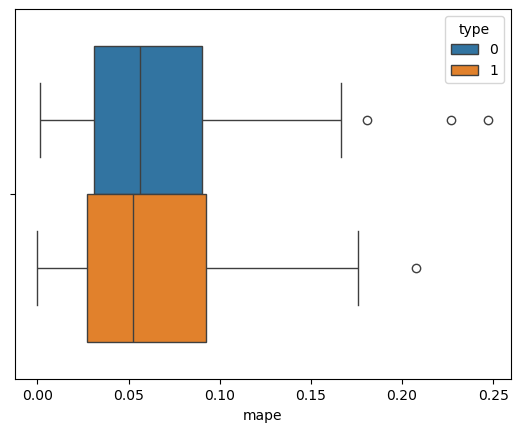

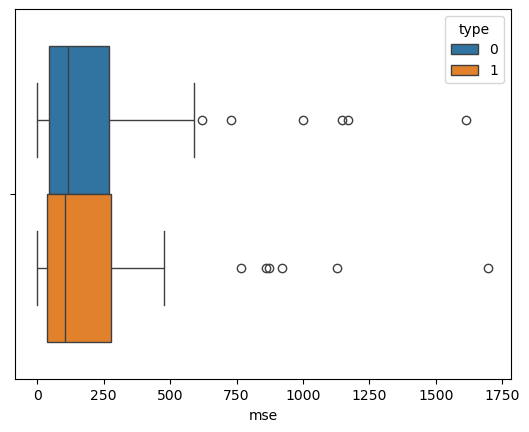

In [297]:
sns.boxplot(general_metrics.loc[:,["mape", "type"]], x = "mape", hue = "type")
plt.show()
sns.boxplot(general_metrics.loc[:,["mse", "type"]], x = "mse", hue = "type")
plt.show()

The best ARIMA model has the following hyperparameters (4,1,3)